In [9]:
from importlib import reload

In [11]:
from src import data_broker

In [13]:
reload(data_broker)

<module 'src.data_broker' from '/Users/zhigangyu/Documents/Project Z/src/data_broker.py'>

In [14]:
# Define a test universe
tickers = ["AAPL", "MSFT", "NVDA", "AMZN"]
broker = data_broker.DataBroker(tickers=tickers, start_date="2024-01-01", end_date="2026-06-01")

In [15]:
# Fetch data
universe_data = broker.fetch_universe_data()

[*********************100%***********************]  2 of 4 completed


In [20]:
# INTERACTIVE CHECK: Did yfinance format correctly? Are there NaNs?
print("Price Matrix Shape:", universe_data["price"].shape)
display(universe_data["price"].tail())  # Visually inspect the last few rows

Price Matrix Shape: (604, 4)


,AAPL,MSFT,NVDA,AMZN
Date,,,,
2026-05-22,308.820007,418.570007,215.079330,266.320007
2026-05-26,308.329987,416.029999,214.609879,265.290009
2026-05-27,310.850006,412.670013,212.352509,271.850006
2026-05-28,312.510010,426.989990,214.000580,274.000000
2026-05-29,312.059998,450.239990,210.894211,270.640015


## verify the split logic

In [21]:
# Test our N_month forward split
is_data, oos_data = broker.split_train_test(universe_data, forward_months=6)

print(f"In-Sample Date Range: {is_data['price'].index[0]} to {is_data['price'].index[-1]}")
print(f"Out-of-Sample Date Range: {oos_data['price'].index[0]} to {oos_data['price'].index[-1]}")

In-Sample Date Range: 2024-01-02 00:00:00 to 2025-11-28 00:00:00
Out-of-Sample Date Range: 2025-12-01 00:00:00 to 2026-05-29 00:00:00


Matplotlib is building the font cache; this may take a moment.


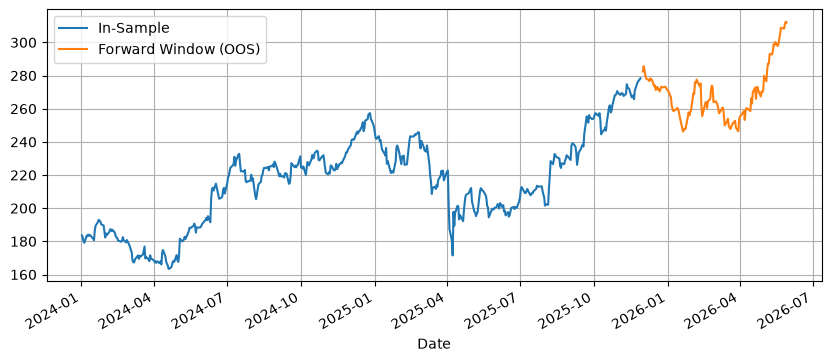

In [23]:
# Quick sanity check plot
is_data["price"]["AAPL"].plot(label="In-Sample", figsize=(10, 4))
oos_data["price"]["AAPL"].plot(label="Forward Window (OOS)", grid=True).legend()